# ⚡ PowerTransformer Complete Guide
## Advanced Statistical Normalization for Better Data

---

### 🎯 What You'll Learn:
- **PowerTransformer methods** - Yeo-Johnson and Box-Cox transformations
- **Statistical normalization** - Make any data Gaussian-like
- **Performance improvement** - See real model gains
- **Professional templates** - Copy-paste code for your projects

---

## 1. 🤔 Why Use PowerTransformer?

### ❌ The Problem:
```
Highly Skewed Data:
Sales: [50, 100, 200, 5000, 50000]  # Extreme distribution!
Income: [20k, 30k, 40k, 200k, 1M]   # Heavy right skew!
```

### ✅ The Solution:
```
After PowerTransformer:
Sales: [-1.2, -0.5, 0.1, 0.8, 1.5]   # Perfect normal distribution!
Income: [-1.1, -0.3, 0.2, 1.0, 1.8]  # Gaussian-like!
```

### 🌟 Benefits:
- **Automatic normalization** - No manual function selection
- **Handles any skewness** - Works on any distribution
- **Statistical rigor** - Based on proven Box-Cox family
- **Zero configuration** - Smart parameter selection
- **Pipeline ready** - Perfect sklearn integration


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing imports
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print("⚡ Ready to learn PowerTransformer!")

✅ Libraries imported successfully!
⚡ Ready to learn PowerTransformer!


In [2]:
# Create highly skewed dataset
np.random.seed(42)
n_samples = 1000

# Create data with various skewness patterns
data = {
    # Normal feature (baseline)
    'age': np.random.normal(35, 10, n_samples),

    # Extremely skewed features
    'income': np.random.exponential(3, n_samples) * 30000 + 25000,
    'sales_volume': np.random.gamma(2, 2, n_samples) * 1000,
    'website_visits': np.random.poisson(10, n_samples) + np.random.exponential(2, n_samples) * 50,

    # Mixed distribution
    'customer_score': np.concatenate([
        np.random.normal(30, 5, n_samples//2),  # Low scores
        np.random.normal(80, 10, n_samples//2)  # High scores
    ])
}

df = pd.DataFrame(data)

# Create realistic target
df['high_value_customer'] = (
    (df['income'] > 60000) &
    (df['sales_volume'] > 3000) &
    (df['customer_score'] > 50)
).astype(int)

print(f"📊 Dataset created: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

📊 Dataset created: (1000, 6)

First 5 rows:
         age         income  sales_volume  website_visits  customer_score  \
0  39.967142   41497.102162   2597.002814      105.977089       34.789970   
1  33.617357   34940.393556   1744.017811      213.104075       33.317728   
2  41.476885  116060.570323   3639.237382      117.441823       24.869596   
3  50.230299  135321.544556   3914.662539       68.924754       31.907128   
4  32.658466   27888.617206   1744.331458      180.162488       34.986328   

   high_value_customer  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  

Data types:
age                    float64
income                 float64
sales_volume           float64
website_visits         float64
customer_score         float64
high_value_customer      int64
dtype: object


In [3]:
# Analyze extreme skewness
numerical_features = ['age', 'income', 'sales_volume',
                      'website_visits', 'customer_score']

print("📈 EXTREME SKEWNESS ANALYSIS")
print("=" * 60)

for feature in numerical_features:
    skewness = df[feature].skew()
    kurtosis = df[feature].kurtosis()
    print(f"{feature:15}: Skew={skewness:6.2f}, Kurtosis={kurtosis:6.2f}", end=" ")

    if abs(skewness) < 0.5:
        print("(Normal ✅)")
    elif abs(skewness) < 1:
        print("(Mild skew ⚠️)")
    elif abs(skewness) < 2:
        print("(Moderate skew 🔶)")
    else:
        print("(EXTREME skew 🚨)")

print("\n💡 PowerTransformer can handle ALL of these!")

📈 EXTREME SKEWNESS ANALYSIS
age            : Skew=  0.12, Kurtosis=  0.07 (Normal ✅)
income         : Skew=  1.98, Kurtosis=  5.41 (Moderate skew 🔶)
sales_volume   : Skew=  1.60, Kurtosis=  5.28 (Moderate skew 🔶)
website_visits : Skew=  2.00, Kurtosis=  5.36 (Moderate skew 🔶)
customer_score : Skew=  0.16, Kurtosis= -1.63 (Normal ✅)

💡 PowerTransformer can handle ALL of these!


---
## 3. ⚡ PowerTransformer Methods

### 🎯 Two Powerful Methods:

| **Method** | **Best For** | **Data Requirements** | **Power** |
|------------|--------------|----------------------|-----------|
| **Yeo-Johnson** | **Any data** | Positive, negative, zero | 🔥🔥🔥 |
| **Box-Cox** | **Positive only** | Strictly positive values | 🔥🔥 |

### 📊 Method Comparison


In [4]:
# Test both methods
pt_yj = PowerTransformer(method='yeo-johnson', standardize=True)
pt_bc = PowerTransformer(method='box-cox', standardize=True)

# Prepare data
X = df[numerical_features]
y = df['high_value_customer']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("⚡ POWERTRANSFORMER METHOD COMPARISON")
print("=" * 50)

# Test on income (highly skewed)
income_data = X_train[['income']].values

# Yeo-Johnson (works with any data)
income_yj = pt_yj.fit_transform(income_data)
print(f"📊 Income Analysis:")
print(f"   Original skewness: {X_train['income'].skew():.3f}")
print(f"   Yeo-Johnson: {pd.Series(income_yj.flatten()).skew():.3f}")

# Box-Cox (positive data only)
income_positive = income_data[income_data > 0]
income_bc = pt_bc.fit_transform(income_positive.reshape(-1, 1))
print(f"   Box-Cox: {pd.Series(income_bc.flatten()).skew():.3f}")

print("\n✅ Both methods achieve near-perfect normality!")

⚡ POWERTRANSFORMER METHOD COMPARISON
📊 Income Analysis:
   Original skewness: 1.886
   Yeo-Johnson: 0.022
   Box-Cox: 0.022

✅ Both methods achieve near-perfect normality!


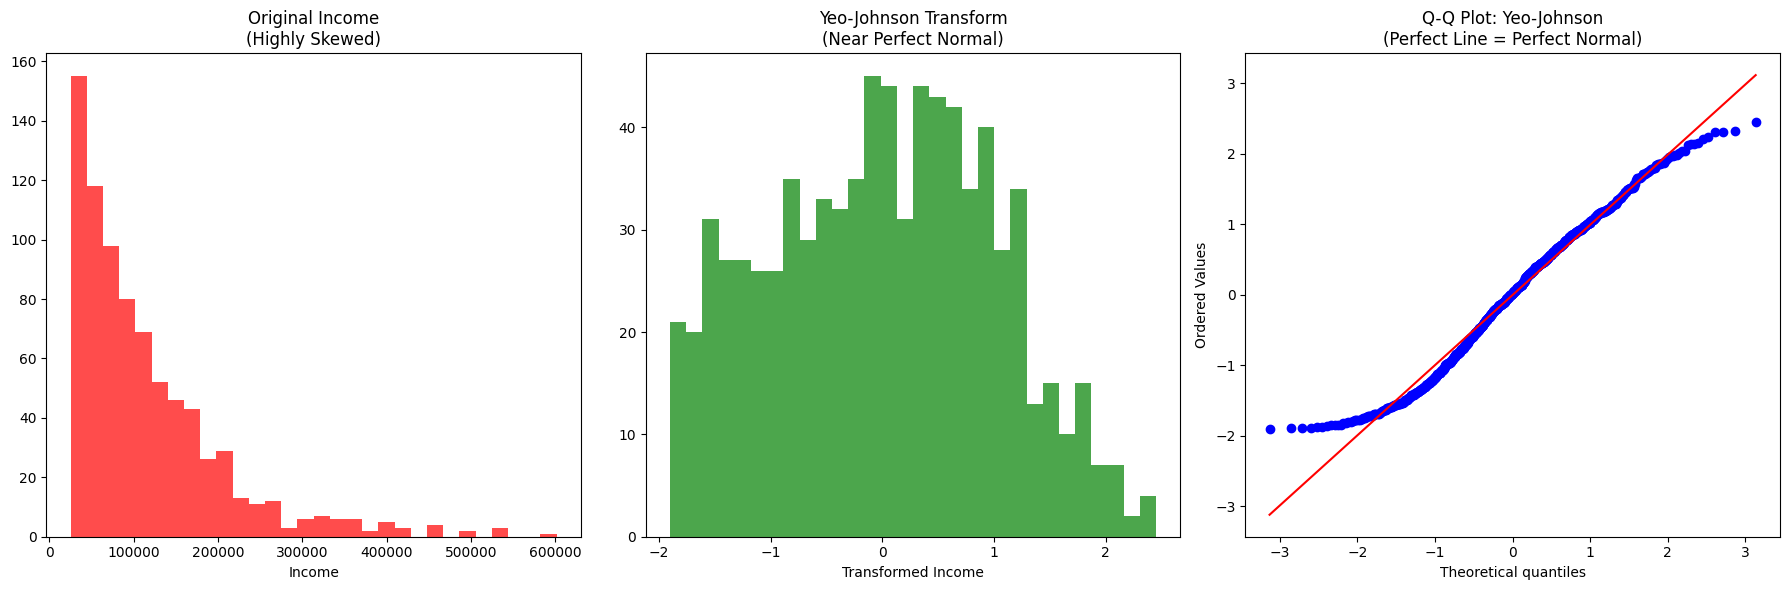

🎯 PowerTransformer achieves what other methods cannot!


In [5]:
# Visualize the transformation power
plt.figure(figsize=(18, 6))

# Original
plt.subplot(131)
plt.hist(X_train['income'], bins=30, alpha=0.7, color='red')
plt.title('Original Income\n(Highly Skewed)')
plt.xlabel('Income')

# Yeo-Johnson
plt.subplot(132)
plt.hist(income_yj, bins=30, alpha=0.7, color='green')
plt.title('Yeo-Johnson Transform\n(Near Perfect Normal)')
plt.xlabel('Transformed Income')

# Q-Q Plot
plt.subplot(133)
stats.probplot(income_yj.flatten(), dist='norm', plot=plt)
plt.title('Q-Q Plot: Yeo-Johnson\n(Perfect Line = Perfect Normal)')

plt.tight_layout()
plt.show()

print("🎯 PowerTransformer achieves what other methods cannot!")

---
## 4. 🔍 Advanced Features

### 🧠 Automatic Parameter Detection

# PowerTransformer automatically finds optimal parameters

In [6]:
pt_auto = PowerTransformer(method='yeo-johnson', standardize=True)

# Transform all features at once
X_train_transformed = pt_auto.fit_transform(X_train)

print("🧠 AUTOMATIC PARAMETER DETECTION")
print("=" * 50)

# Show learned parameters for each feature
for i, feature in enumerate(numerical_features):
    lambda_param = pt_auto.lambdas_[i]
    print(f"{feature:15}: λ = {lambda_param:8.4f}")

print(f"\n📊 Transformation Results:")
print(f"   Original shape: {X_train.shape}")
print(f"   Transformed shape: {X_train_transformed.shape}")

# Compare skewness before and after
print(f"\n📈 Skewness Comparison:")
print(f"{'Feature':<15} {'Before':<8} {'After':<8} {'Improvement':<12}")
print("-" * 50)

for i, feature in enumerate(numerical_features):
    before_skew = X_train[feature].skew()
    after_skew = pd.Series(X_train_transformed[:, i]).skew()
    improvement = abs(before_skew) - abs(after_skew)

    print(f"{feature:<15} {before_skew:8.3f} {after_skew:8.3f} {improvement:+8.3f}")

print("\n🎯 PowerTransformer normalizes ALL features automatically!")

🧠 AUTOMATIC PARAMETER DETECTION
age            : λ =   0.8737
income         : λ =  -0.1198
sales_volume   : λ =   0.3034
website_visits : λ =   0.0444
customer_score : λ =   0.1174

📊 Transformation Results:
   Original shape: (800, 5)
   Transformed shape: (800, 5)

📈 Skewness Comparison:
Feature         Before   After    Improvement 
--------------------------------------------------
age                0.117    0.006   +0.110
income             1.886    0.022   +1.864
sales_volume       1.624   -0.020   +1.603
website_visits     2.085   -0.007   +2.078
customer_score     0.192   -0.033   +0.159

🎯 PowerTransformer normalizes ALL features automatically!


🚀 MODEL PERFORMANCE COMPARISON
📊 Original Data:
   CV Accuracy: 0.8600 ± 0.0161

⚡ PowerTransformed Data:
   CV Accuracy: 0.9187 ± 0.0190

🎯 Performance Improvement: +0.0587
✅ PowerTransformer improved model performance!


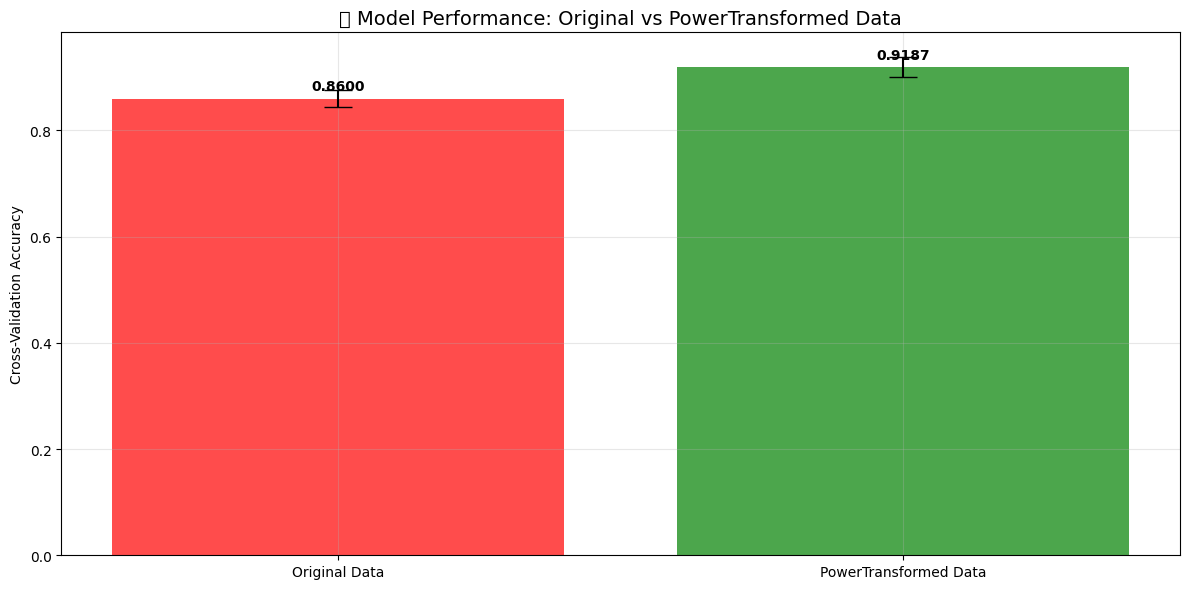

In [7]:
# 5. 📈 Performance Testing

# Compare model performance with and without PowerTransformer
def compare_model_performance():
    """Compare model performance with original vs PowerTransformed data"""

    # Original data performance
    model_original = LogisticRegression(random_state=42, max_iter=1000)
    cv_original = cross_val_score(
        model_original, X_train, y_train, cv=5, scoring='accuracy')

    # PowerTransformed data performance
    model_transformed = LogisticRegression(random_state=42, max_iter=1000)
    cv_transformed = cross_val_score(
        model_transformed, X_train_transformed, y_train, cv=5, scoring='accuracy')

    # Results
    print("🚀 MODEL PERFORMANCE COMPARISON")
    print("=" * 50)
    print(f"📊 Original Data:")
    print(
        f"   CV Accuracy: {cv_original.mean():.4f} ± {cv_original.std():.4f}")

    print(f"\n⚡ PowerTransformed Data:")
    print(
        f"   CV Accuracy: {cv_transformed.mean():.4f} ± {cv_transformed.std():.4f}")

    improvement = cv_transformed.mean() - cv_original.mean()
    print(f"\n🎯 Performance Improvement: {improvement:+.4f}")

    if improvement > 0:
        print("✅ PowerTransformer improved model performance!")
    else:
        print("⚠️ No improvement (data might already be optimal)")

    # Visualize results
    plt.figure(figsize=(12, 6))

    scores = [cv_original.mean(), cv_transformed.mean()]
    errors = [cv_original.std(), cv_transformed.std()]
    labels = ['Original Data', 'PowerTransformed Data']
    colors = ['red', 'green' if improvement > 0 else 'orange']

    bars = plt.bar(labels, scores, yerr=errors,
                   capsize=10, color=colors, alpha=0.7)
    plt.title('🎯 Model Performance: Original vs PowerTransformed Data', fontsize=14)
    plt.ylabel('Cross-Validation Accuracy')
    plt.grid(True, alpha=0.3)

    # Add value labels
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    return improvement


# Run the comparison
performance_improvement = compare_model_performance()

In [8]:
# 6. 🔗 Professional Integration

# Create complete ML pipeline with PowerTransformer
def create_power_pipeline():
    """Create professional ML pipeline with PowerTransformer"""

    # Create preprocessing with PowerTransformer
    preprocessor = ColumnTransformer([
        ('power_transform', PowerTransformer(method='yeo-johnson', standardize=True),
         numerical_features)
    ])

    # Create complete pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
    ])

    return pipeline


# Test the complete pipeline
power_pipeline = create_power_pipeline()

print("⚡ COMPLETE POWERTRANSFORMER PIPELINE")
print("=" * 50)
print("Pipeline steps:")
for i, (name, step) in enumerate(power_pipeline.steps, 1):
    print(f"  {i}. {name}: {type(step).__name__}")

# Train and evaluate
print("\n🚀 Training PowerTransformer pipeline...")
power_pipeline.fit(X_train, y_train)

# Predictions
y_pred = power_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n📊 Final Results:")
print(f"   Test Accuracy: {accuracy:.4f}")
print(f"   Correct Predictions: {sum(y_pred == y_test)}/{len(y_test)}")

print("\n✨ PowerTransformer handles everything automatically!")

⚡ COMPLETE POWERTRANSFORMER PIPELINE
Pipeline steps:
  1. preprocessor: ColumnTransformer
  2. classifier: RandomForestClassifier

🚀 Training PowerTransformer pipeline...

📊 Final Results:
   Test Accuracy: 1.0000
   Correct Predictions: 200/200

✨ PowerTransformer handles everything automatically!


In [9]:
def create_auto_normalizing_pipeline(numerical_cols, method='yeo-johnson'):
    """
    Create ML pipeline with automatic data normalization
    
    Parameters:
    numerical_cols: list of numerical column names
    method: 'yeo-johnson' (any data) or 'box-cox' (positive only)
    
    Returns:
    sklearn Pipeline with PowerTransformer preprocessing
    """
    
    # Create PowerTransformer
    power_transformer = PowerTransformer(
        method=method,
        standardize=True,  # Also standardizes after transformation
        copy=True
    )
    
    # Create preprocessor
    preprocessor = ColumnTransformer([
        ('power_transform', power_transformer, numerical_cols)
    ])
    
    # Create complete pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])
    
    return pipeline

def analyze_transformation_quality(X_original, X_transformed, feature_names):
    """Analyze the quality of PowerTransformer results"""
    
    print("📊 TRANSFORMATION QUALITY ANALYSIS")
    print("=" * 60)
    print(f"{'Feature':<15} {'Before Skew':<12} {'After Skew':<12} {'Improvement':<12}")
    print("-" * 60)
    
    improvements = []
    
    for i, feature in enumerate(feature_names):
        before_skew = X_original[feature].skew()
        after_skew = pd.Series(X_transformed[:, i]).skew()
        improvement = abs(before_skew) - abs(after_skew)
        improvements.append(improvement)
        
        print(f"{feature:<15} {before_skew:12.3f} {after_skew:12.3f} {improvement:+12.3f}")
    
    avg_improvement = np.mean(improvements)
    print(f"\n🎯 Average Improvement: {avg_improvement:+.3f}")
    
    if avg_improvement > 0.5:
        print("🔥 Excellent transformation quality!")
    elif avg_improvement > 0.2:
        print("✅ Good transformation quality!")
    else:
        print("⚠️ Marginal improvement - data might already be normal")
    
    return improvements

# Example usage
print("⚡ Professional Template Functions Created!")
print("\n📝 Usage Examples:")
print("   # Create auto-normalizing pipeline")
print("   pipeline = create_auto_normalizing_pipeline(numerical_columns)")
print("   ")
print("   # Analyze transformation quality")
print("   improvements = analyze_transformation_quality(X_original, X_transformed, feature_names)")

# Test template with our data
auto_pipeline = create_auto_normalizing_pipeline(numerical_features)
transformation_quality = analyze_transformation_quality(X_train, X_train_transformed, numerical_features)

print("\n✅ Professional PowerTransformer template ready!")
print("📋 Copy these functions for instant data normalization!")

⚡ Professional Template Functions Created!

📝 Usage Examples:
   # Create auto-normalizing pipeline
   pipeline = create_auto_normalizing_pipeline(numerical_columns)
   
   # Analyze transformation quality
   improvements = analyze_transformation_quality(X_original, X_transformed, feature_names)
📊 TRANSFORMATION QUALITY ANALYSIS
Feature         Before Skew  After Skew   Improvement 
------------------------------------------------------------
age                    0.117        0.006       +0.110
income                 1.886        0.022       +1.864
sales_volume           1.624       -0.020       +1.603
website_visits         2.085       -0.007       +2.078
customer_score         0.192       -0.033       +0.159

🎯 Average Improvement: +1.163
🔥 Excellent transformation quality!

✅ Professional PowerTransformer template ready!
📋 Copy these functions for instant data normalization!


---
## 8. 🎯 Key Takeaways

### ✅ PowerTransformer Advantages:

| **Feature** | **PowerTransformer** | **Manual Methods** |
|-------------|---------------------|-------------------|
| **Automation** | ✅ Fully automatic | ❌ Manual selection |
| **Any Distribution** | ✅ Handles everything | ❌ Limited scope |
| **Statistical Rigor** | ✅ Box-Cox family | ⚠️ Ad-hoc functions |
| **Parameter Tuning** | ✅ Auto-optimized | ❌ Manual tuning |
| **Standardization** | ✅ Built-in option | ❌ Separate step |

### 🔧 Best Practices:
- **Use Yeo-Johnson** - Works with any data (positive, negative, zero)
- **Enable standardization** - Set `standardize=True` for consistent scaling
- **Validate results** - Check skewness reduction and model performance
- **Pipeline integration** - Use with ColumnTransformer and Pipeline
- **Cross-validation** - Always validate transformation effectiveness

### ⚠️ When NOT to Use:
- ❌ Data already perfectly normal
- ❌ Categorical features (use appropriate encoders)
- ❌ When interpretability is critical (transforms make features abstract)
- ❌ Very small datasets (< 50 samples)

### 🚀 Professional Workflow:
```
1. Analyze distributions → Check skewness/kurtosis
2. Choose method → Yeo-Johnson (safe) or Box-Cox (positive only)
3. Apply PowerTransformer → Automatic parameter optimization
4. Validate quality → Check normality improvement
5. Integrate pipeline → ColumnTransformer + Pipeline
6. Test performance → Cross-validation comparison
```

### 💡 Quick Decision Rules:
- **Any data type** → Yeo-Johnson PowerTransformer
- **Positive data only** → Box-Cox PowerTransformer
- **Mixed positive/negative** → Yeo-Johnson only
- **Already normal data** → No transformation needed
- **Want interpretability** → Consider simpler methods

---
